In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, ConfusionMatrixDisplay)
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")
print("Libraries loaded successfully")

Libraries loaded successfully


In [18]:
df = pd.read_csv('ASHRAE_DB2.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Dataset shape: (107583, 70)

Columns:
['Publication (Citation)', 'Data contributor', 'Year', 'Season', 'Koppen climate classification', 'Climate', 'City', 'Country', 'Building type', 'Cooling startegy_building level', 'Cooling startegy_operation mode for MM buildings', 'Heating strategy_building level', 'Age', 'Sex', 'Thermal sensation', 'Thermal sensation acceptability', 'Thermal preference', 'Air movement acceptability', 'Air movement preference', 'Thermal comfort', 'PMV', 'PPD', 'SET', 'Clo', 'Met', 'activity_10', 'activity_20', 'activity_30', 'activity_60', 'Air temperature (C)', 'Air temperature (F)', 'Ta_h (C)', 'Ta_h (F)', 'Ta_m (C)', 'Ta_m (F)', 'Ta_l (C)', 'Ta_l (F)', 'Operative temperature (C)', 'Operative temperature (F)', 'Radiant temperature (C)', 'Radiant temperature (F)', 'Globe temperature (C)', 'Globe temperature (F)', 'Tg_h (C)', 'Tg_h (F)', 'Tg_m (C)', 'Tg_m (F)', 'Tg_l (C)', 'Tg_l (F)', 'Relative humidity (%)', 'Humidity preference', 'Humidity sensation', 'Air veloc

,Publication (Citation),Data contributor,Year,Season,Koppen climate classification,Climate,City,Country,Building type,Cooling startegy_building level,...,Subject«s height (cm),Subject«s weight (kg),Blind (curtain),Fan,Window,Door,Heater,Outdoor monthly air temperature (C),Outdoor monthly air temperature (F),Database
0,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,162.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
1,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,154.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
2,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,173.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
3,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,167.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
4,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,178.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2


In [19]:
# Check what columns relate to thermal sensation
tsv_cols = [c for c in df.columns if 'thermal' in c.lower() or 'sensation' in c.lower() or 'tsv' in c.lower()]
print("Possible target columns:", tsv_cols)

# Check unique values
for col in tsv_cols:
    print(f"\n{col}: {df[col].unique()}")

Possible target columns: ['Thermal sensation', 'Thermal sensation acceptability', 'Thermal preference', 'Thermal comfort', 'Humidity sensation']

Thermal sensation: [-0.5  -2.1   0.5  -2.5   1.   -1.   -1.5  -3.    0.   -2.   -0.2   1.5
  2.5  -0.3   1.3  -1.8  -1.3  -1.4   0.6   1.6   1.2   2.    0.7   0.3
  3.     nan -0.6   2.8  -0.1   1.1   0.1  -1.1   2.6   2.9   2.1   1.4
  0.8  -1.7   1.8   2.7  -0.7  -0.8  -0.4  -1.9  -0.9  -2.9  -2.6  -2.3
 -2.2   0.2  -1.6   1.9   0.4   0.9  -2.8  -2.4  -1.2   1.7   2.2   1.08
  2.3   2.4  -2.7 ]

Thermal sensation acceptability: [ 1.  0. nan]

Thermal preference: ['warmer' 'no change' 'cooler' nan]

Thermal comfort: [5.0 6.0 4.0 1.0 3.0 2.0 4.5 5.2 2.5 2.7 2.2 2.3 2.8 4.3 2.4 4.2 3.5 nan
 1.8 'Na' '2.6' '5.1' '1.7' '3.4' '0.9' '4.3' '6' '5' '4' '2' '3' '1' 1.3
 1.5 ' ']

Humidity sensation: [nan -1. -3.  0.  1.  2. -2.  3.]


In [20]:
# The 6 input features + target
feature_cols = {
    'Ta': None,   # Air temperature
    'Tr': None,   # Mean Radiant Temperature  
    'RH': None,   # Relative Humidity
    'Va': None,   # Air Velocity (sometimes 'v' or 'Air vel')
    'Met': None,  # Metabolic rate
    'Clo': None,  # Clothing insulation
}

# Print all columns to find exact names
print(df.columns.tolist())

['Publication (Citation)', 'Data contributor', 'Year', 'Season', 'Koppen climate classification', 'Climate', 'City', 'Country', 'Building type', 'Cooling startegy_building level', 'Cooling startegy_operation mode for MM buildings', 'Heating strategy_building level', 'Age', 'Sex', 'Thermal sensation', 'Thermal sensation acceptability', 'Thermal preference', 'Air movement acceptability', 'Air movement preference', 'Thermal comfort', 'PMV', 'PPD', 'SET', 'Clo', 'Met', 'activity_10', 'activity_20', 'activity_30', 'activity_60', 'Air temperature (C)', 'Air temperature (F)', 'Ta_h (C)', 'Ta_h (F)', 'Ta_m (C)', 'Ta_m (F)', 'Ta_l (C)', 'Ta_l (F)', 'Operative temperature (C)', 'Operative temperature (F)', 'Radiant temperature (C)', 'Radiant temperature (F)', 'Globe temperature (C)', 'Globe temperature (F)', 'Tg_h (C)', 'Tg_h (F)', 'Tg_m (C)', 'Tg_m (F)', 'Tg_l (C)', 'Tg_l (F)', 'Relative humidity (%)', 'Humidity preference', 'Humidity sensation', 'Air velocity (m/s)', 'Air velocity (fpm)', 'Vel

In [21]:
print(df.columns.tolist())

['Publication (Citation)', 'Data contributor', 'Year', 'Season', 'Koppen climate classification', 'Climate', 'City', 'Country', 'Building type', 'Cooling startegy_building level', 'Cooling startegy_operation mode for MM buildings', 'Heating strategy_building level', 'Age', 'Sex', 'Thermal sensation', 'Thermal sensation acceptability', 'Thermal preference', 'Air movement acceptability', 'Air movement preference', 'Thermal comfort', 'PMV', 'PPD', 'SET', 'Clo', 'Met', 'activity_10', 'activity_20', 'activity_30', 'activity_60', 'Air temperature (C)', 'Air temperature (F)', 'Ta_h (C)', 'Ta_h (F)', 'Ta_m (C)', 'Ta_m (F)', 'Ta_l (C)', 'Ta_l (F)', 'Operative temperature (C)', 'Operative temperature (F)', 'Radiant temperature (C)', 'Radiant temperature (F)', 'Globe temperature (C)', 'Globe temperature (F)', 'Tg_h (C)', 'Tg_h (F)', 'Tg_m (C)', 'Tg_m (F)', 'Tg_l (C)', 'Tg_l (F)', 'Relative humidity (%)', 'Humidity preference', 'Humidity sensation', 'Air velocity (m/s)', 'Air velocity (fpm)', 'Vel

In [22]:
features = ['Air temperature (C)', 'Radiant temperature (C)', 
            'Relative humidity (%)', 'Air velocity (m/s)',
            'Met', 'Clo']
target = 'Thermal sensation'

# Create working dataframe
data = df[features + [target]].copy()
data.columns = ['Ta', 'Tr', 'RH', 'Va', 'Met', 'Clo', 'TSV']
print(data.shape)
data.head()

(107583, 7)


,Ta,Tr,RH,Va,Met,Clo,TSV
0,24.2,NaN,50.2,0.06,NaN,0.25,-0.5
1,24.2,NaN,50.2,0.06,NaN,0.25,-2.1
2,24.2,NaN,50.2,0.06,NaN,0.27,0.5
3,24.2,NaN,50.2,0.06,NaN,0.23,-2.5
4,24.2,NaN,50.2,0.06,NaN,0.34,-0.5


In [23]:
print("=== Basic Statistics ===")
data.describe()

=== Basic Statistics ===


,Ta,Tr,RH,Va,Met,Clo,TSV
count,99911.000000,32473.000000,97762.000000,89892.000000,90419.000000,99663.000000,104454.000000
mean,24.496358,24.602735,47.548068,0.175384,1.206626,0.673669,0.167892
std,3.782002,4.257815,15.760944,0.405937,0.248939,0.287622,1.241041
min,0.600000,1.200000,0.000000,0.000000,0.650000,0.000000,-3.000000
25%,22.300000,22.400000,35.300000,0.040000,1.060000,0.490000,-0.500000
50%,23.900000,24.000000,47.200000,0.090000,1.200000,0.630000,0.000000
75%,26.400000,27.000000,59.400000,0.190000,1.200000,0.780000,1.000000
max,63.200000,148.100000,100.000000,56.170000,6.830000,2.890000,3.000000


     Missing  Percentage
Ta      7672    7.131238
Tr     75110   69.815863
RH      9821    9.128766
Va     17691   16.444048
Met    17164   15.954194
Clo     7920    7.361758
TSV     3129    2.908452


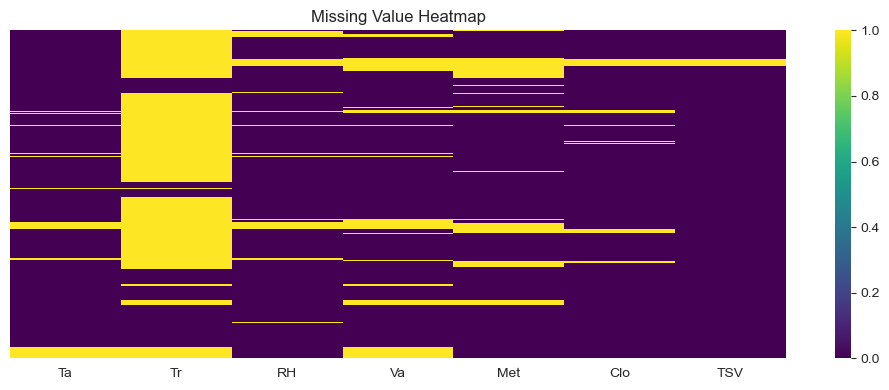

In [24]:
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

# Visualize
plt.figure(figsize=(10, 4))
sns.heatmap(data.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()

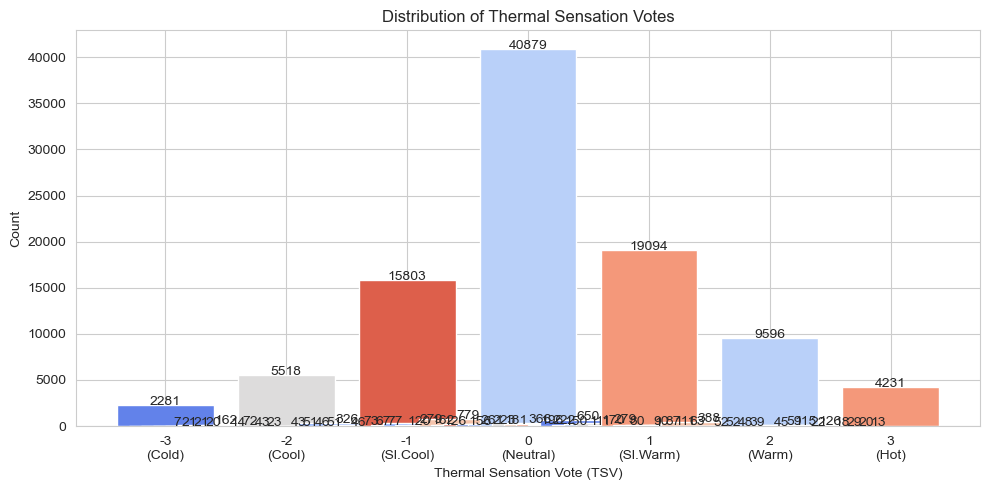


Class distribution:
TSV
-3.0    2281
-2.9       7
-2.8      21
-2.7      21
-2.6      20
        ... 
 2.6      18
 2.7      29
 2.8      20
 2.9      13
 3.0    4231
Name: count, Length: 62, dtype: int64


In [25]:
plt.figure(figsize=(10, 5))
tsv_labels = {-3:'Cold', -2:'Cool', -1:'Sl.Cool', 0:'Neutral', 
               1:'Sl.Warm', 2:'Warm', 3:'Hot'}
counts = data['TSV'].value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color=sns.color_palette("coolwarm", 7))
plt.xticks(range(-3, 4), [f"{k}\n({v})" for k, v in tsv_labels.items()])
plt.xlabel('Thermal Sensation Vote (TSV)')
plt.ylabel('Count')
plt.title('Distribution of Thermal Sensation Votes')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print(f"\nClass distribution:\n{counts}")

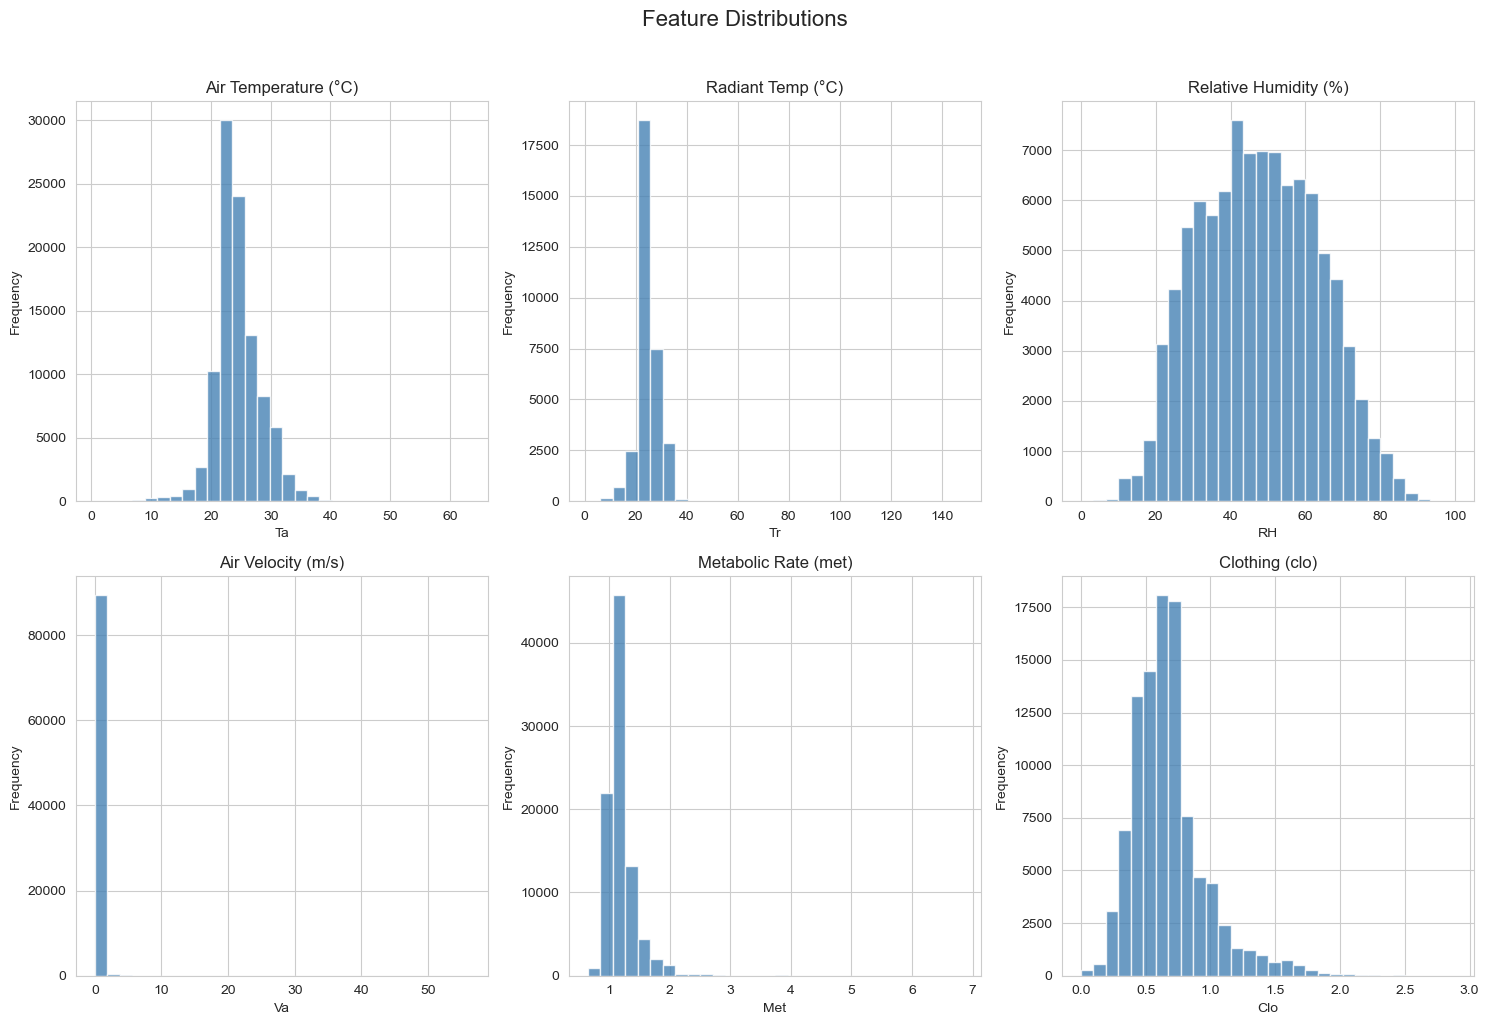

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_plot = ['Ta', 'Tr', 'RH', 'Va', 'Met', 'Clo']
titles = ['Air Temperature (°C)', 'Radiant Temp (°C)', 'Relative Humidity (%)',
          'Air Velocity (m/s)', 'Metabolic Rate (met)', 'Clothing (clo)']

for ax, feat, title in zip(axes.flatten(), features_plot, titles):
    ax.hist(data[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

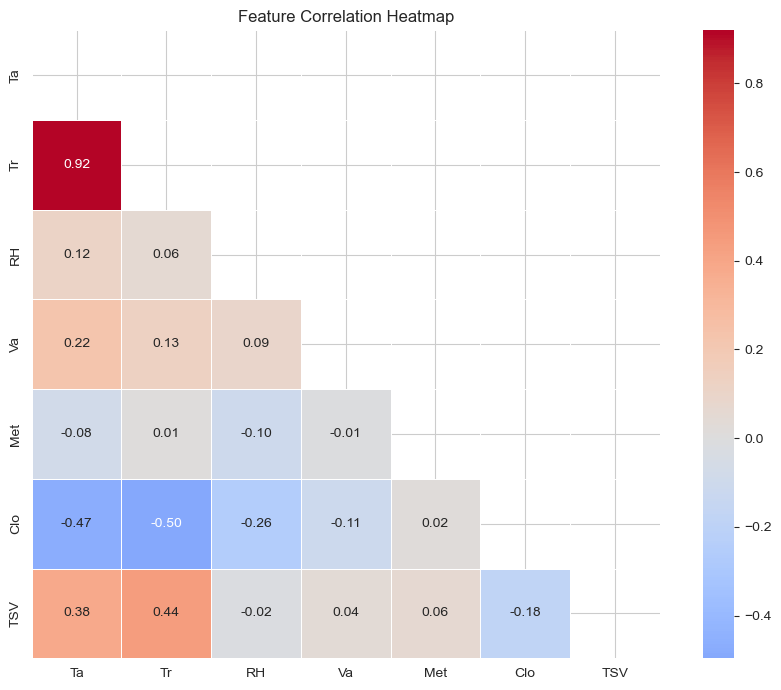

In [27]:
plt.figure(figsize=(9, 7))
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

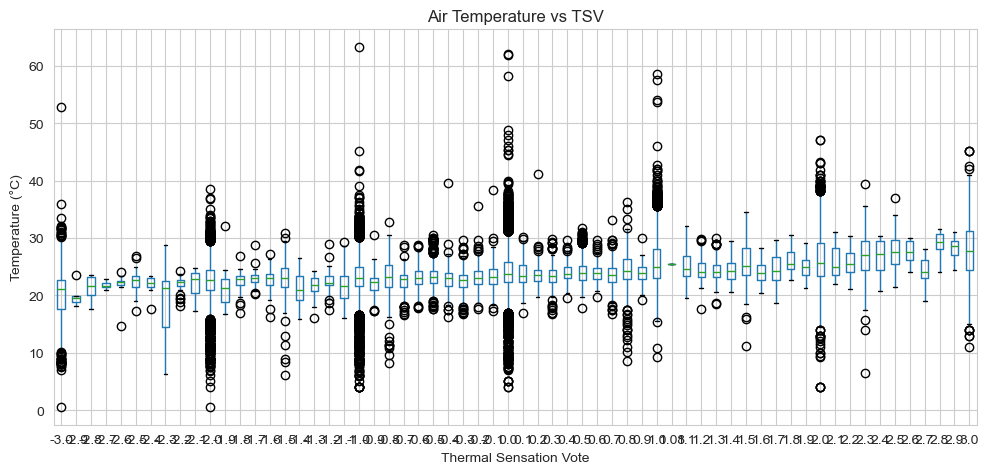

In [28]:
plt.figure(figsize=(10, 5))
data.boxplot(column='Ta', by='TSV', figsize=(10,5))
plt.suptitle('')
plt.title('Air Temperature vs TSV')
plt.xlabel('Thermal Sensation Vote')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

In [29]:
from sklearn.utils import resample

print(f"Original shape: {data.shape}")

# Remove missing values
data_clean = data.dropna()
print(f"After dropping NaN: {data_clean.shape}")

# Remove physical impossibilities
data_clean = data_clean[
    (data_clean['Ta'].between(-20, 50)) &
    (data_clean['RH'].between(0, 100)) &
    (data_clean['Va'] >= 0) &
    (data_clean['Met'].between(0.5, 10)) &
    (data_clean['Clo'].between(0, 5))
]

# ── Simplify: 7 classes → 3 classes ──
# -3, -2, -1  →  0 (Cool/Cold)
#  0          →  1 (Comfortable/Neutral)
# +1, +2, +3  →  2 (Warm/Hot)

data_clean = data_clean[data_clean['TSV'].between(-3, 3)].copy()
data_clean['TSV'] = data_clean['TSV'].astype(int)

def map_tsv(tsv):
    if tsv <= -1:
        return 0   # Cool
    elif tsv == 0:
        return 1   # Comfortable
    else:
        return 2   # Warm

data_clean['TSV'] = data_clean['TSV'].apply(map_tsv)

print(f"\nAfter mapping to 3 classes:")
print(data_clean['TSV'].value_counts().sort_index())
print({0: 'Cool', 1: 'Comfortable', 2: 'Warm'})

# ── Balance classes to 5000 each ──
target_count = 5000
balanced_dfs = []

for tsv_class in sorted(data_clean['TSV'].unique()):
    class_df = data_clean[data_clean['TSV'] == tsv_class]
    if len(class_df) >= target_count:
        class_balanced = resample(class_df, replace=False,
                                  n_samples=target_count, random_state=42)
    else:
        class_balanced = resample(class_df, replace=True,
                                  n_samples=target_count, random_state=42)
    balanced_dfs.append(class_balanced)

data_clean = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nAfter balancing: {data_clean.shape}")
print(f"Final distribution:\n{data_clean['TSV'].value_counts().sort_index()}")

Original shape: (107583, 7)
After dropping NaN: (30651, 7)

After mapping to 3 classes:
TSV
0     6991
1    13393
2    10267
Name: count, dtype: int64
{0: 'Cool', 1: 'Comfortable', 2: 'Warm'}

After balancing: (15000, 7)
Final distribution:
TSV
0    5000
1    5000
2    5000
Name: count, dtype: int64


In [30]:
# Feature engineering — create new meaningful features
data_clean['Ta_RH'] = data_clean['Ta'] * data_clean['RH'] / 100  # Heat index proxy
data_clean['operative_temp'] = (data_clean['Ta'] + data_clean['Tr']) / 2  # Operative temp
data_clean['cooling_effect'] = data_clean['Va'] * (data_clean['Ta'] - 20)  # Wind cooling
data_clean['insulation_activity'] = data_clean['Clo'] * data_clean['Met']  # Body heat retention

print("New features added:")
print(data_clean[['Ta_RH', 'operative_temp', 'cooling_effect', 'insulation_activity']].describe())

New features added:
              Ta_RH  operative_temp  cooling_effect  insulation_activity
count  15000.000000    15000.000000    15000.000000         15000.000000
mean      11.817376       24.058883        0.821465             0.813361
std        4.305391        4.152503        9.022469             0.414811
min        0.126600        5.100000    -1076.118000             0.044500
25%        9.033975       22.100000        0.090000             0.534000
50%       11.393700       23.550000        0.288000             0.720000
75%       14.062625       26.050000        0.730000             0.977600
max       31.537000       85.800000       44.640000             3.929200


In [31]:
X = data_clean[['Ta', 'Tr', 'RH', 'Va', 'Met', 'Clo',
                 'Ta_RH', 'operative_temp', 'cooling_effect', 'insulation_activity']]
y = data_clean['TSV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features: {X.shape[1]}")

Training samples: 12000
Testing samples:  3000
Features: 10


In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaler mean:", scaler.mean_.round(3))
print("Scaler std: ", scaler.scale_.round(3))

Scaler mean: [23.881 24.224 49.454  0.168  1.221  0.67  11.822 24.053  0.8    0.814]
Scaler std:  [ 4.121  4.532 14.648  0.555  0.279  0.311  4.313  4.188 10.041  0.417]


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print("Model training complete!")

Training Accuracy: 0.6505 (65.05%)
Model training complete!


In [34]:
y_pred = model.predict(X_test_scaled)

train_acc = model.score(X_train_scaled, y_train)
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Testing Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")

print("\n=== Classification Report ===")
class_names = ['Cool (<=−1)', 'Comfortable (0)', 'Warm (>=+1)']
print(classification_report(y_test, y_pred, target_names=class_names))

Training Accuracy: 0.6505 (65.05%)
Testing Accuracy:  0.5363 (53.63%)

=== Classification Report ===
                 precision    recall  f1-score   support

    Cool (<=−1)       0.57      0.59      0.58      1000
Comfortable (0)       0.45      0.44      0.45      1000
    Warm (>=+1)       0.58      0.57      0.58      1000

       accuracy                           0.54      3000
      macro avg       0.54      0.54      0.54      3000
   weighted avg       0.54      0.54      0.54      3000



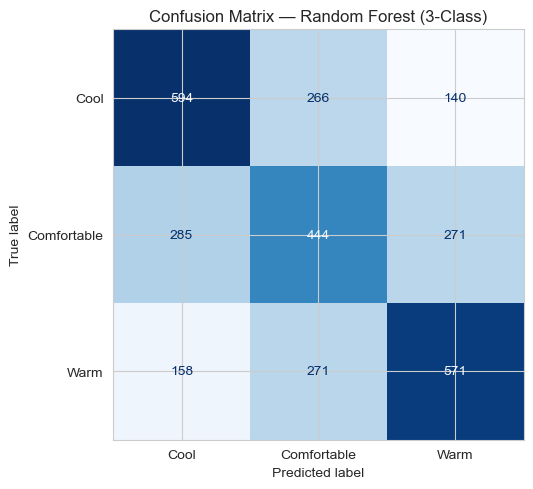

In [35]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Cool', 'Comfortable', 'Warm'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Random Forest (3-Class)')
plt.tight_layout()
plt.show()

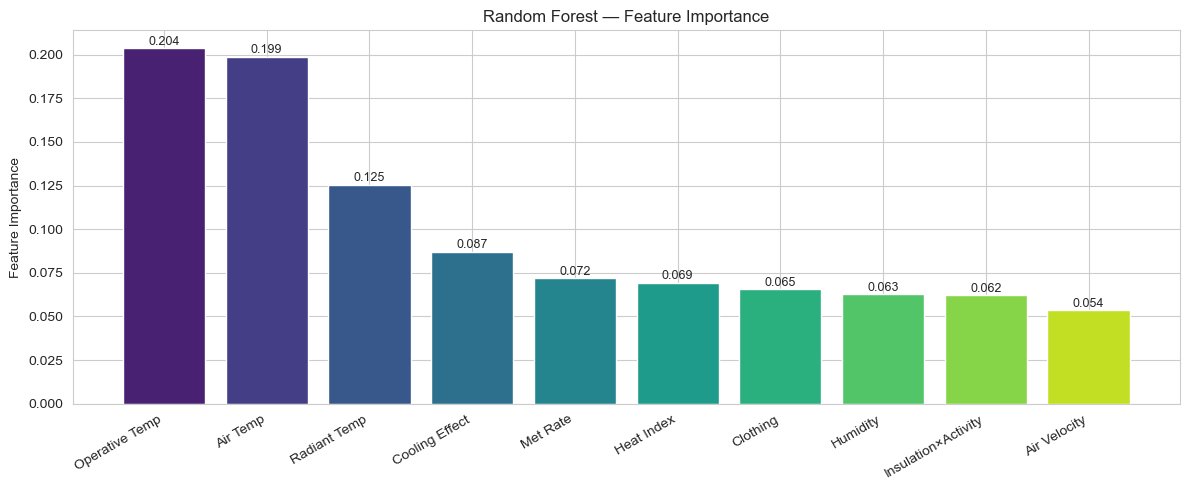

In [36]:
feat_names = ['Air Temp', 'Radiant Temp', 'Humidity', 'Air Velocity', 
              'Met Rate', 'Clothing', 'Heat Index', 
              'Operative Temp', 'Cooling Effect', 'Insulation×Activity']
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 5))
bars = plt.bar(range(10), importances[sorted_idx], 
               color=sns.color_palette("viridis", 10))
plt.xticks(range(10), [feat_names[i] for i in sorted_idx], 
           rotation=30, ha='right')
plt.ylabel('Feature Importance')
plt.title('Random Forest — Feature Importance')
for bar, imp in zip(bars, importances[sorted_idx]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{imp:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [37]:
import os, json
os.makedirs('public/models', exist_ok=True)

with open('public/models/thermal_comfort_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('public/models/thermal_comfort_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

feat_names = ['Air Temp', 'Radiant Temp', 'Humidity', 'Air Velocity',
              'Met Rate', 'Clothing', 'Heat Index',
              'Operative Temp', 'Cooling Effect', 'Insulation×Activity']
importances = model.feature_importances_

metrics = {
    "train_accuracy": round(train_acc, 4),
    "test_accuracy": round(test_acc, 4),
    "model_type": "Random Forest",
    "classes": ["Cool", "Comfortable", "Warm"],
    "features": feat_names,
    "feature_importances": {feat_names[i]: round(float(importances[i]), 4) for i in range(10)}
}
with open('public/models/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("✅ Model saved")
print("✅ Scaler saved")
print("✅ Metrics saved")

✅ Model saved
✅ Scaler saved
✅ Metrics saved


In [38]:
sample_raw = pd.DataFrame([[28, 28, 70, 0.2, 1.2, 0.5]],
                           columns=['Ta', 'Tr', 'RH', 'Va', 'Met', 'Clo'])

# Add engineered features
sample_raw['Ta_RH'] = sample_raw['Ta'] * sample_raw['RH'] / 100
sample_raw['operative_temp'] = (sample_raw['Ta'] + sample_raw['Tr']) / 2
sample_raw['cooling_effect'] = sample_raw['Va'] * (sample_raw['Ta'] - 20)
sample_raw['insulation_activity'] = sample_raw['Clo'] * sample_raw['Met']

sample_scaled = scaler.transform(sample_raw)
pred = model.predict(sample_scaled)[0]
proba = model.predict_proba(sample_scaled)[0]

labels = {0: 'Cool', 1: 'Comfortable', 2: 'Warm'}
print(f"Predicted: {labels[pred]}")
print(f"Confidence: {max(proba)*100:.1f}%")
print(f"Cool: {proba[0]:.2f} | Comfortable: {proba[1]:.2f} | Warm: {proba[2]:.2f}")

Predicted: Warm
Confidence: 43.8%
Cool: 0.23 | Comfortable: 0.33 | Warm: 0.44


In [39]:
print(f"Total samples after cleaning: {len(data_clean)}")
print(f"TSV distribution:\n{data_clean['TSV'].value_counts().sort_index()}")

Total samples after cleaning: 15000
TSV distribution:
TSV
0    5000
1    5000
2    5000
Name: count, dtype: int64


In [40]:
import os
print(os.path.exists('public/models/thermal_comfort_model.pkl'))
print(os.path.exists('public/models/thermal_comfort_scaler.pkl'))
print(os.path.exists('public/models/model_metrics.json'))

True
True
True
